In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#load pre-split data
train = pd.read_csv("data/processed/ea_ml_train.csv")
test  = pd.read_csv("data/processed/ea_ml_test.csv")

print("Train shape:", train.shape, " years:", sorted(train["year"].unique()))
print("Test  shape:", test.shape,  " years:", sorted(test["year"].unique()))

Train shape: (42, 24)  years: [np.int64(2017), np.int64(2018), np.int64(2019)]
Test  shape: (67, 24)  years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
features = [
    "hpi_growth_lag1",
    "hicp_growth_lag1",
    "gdp_growth_lag1",
    "unemp_rate_lag1",
    "marriage_rate_lag1"
]
target = "marriage_rate"

train = train[features + [target]].dropna().reset_index(drop=True)
test  = test[features  + [target]].dropna().reset_index(drop=True)

print("Train rows:", len(train))
print("Test  rows:", len(test))

Train rows: 42
Test  rows: 67


KeyError: 'marriage_rate'

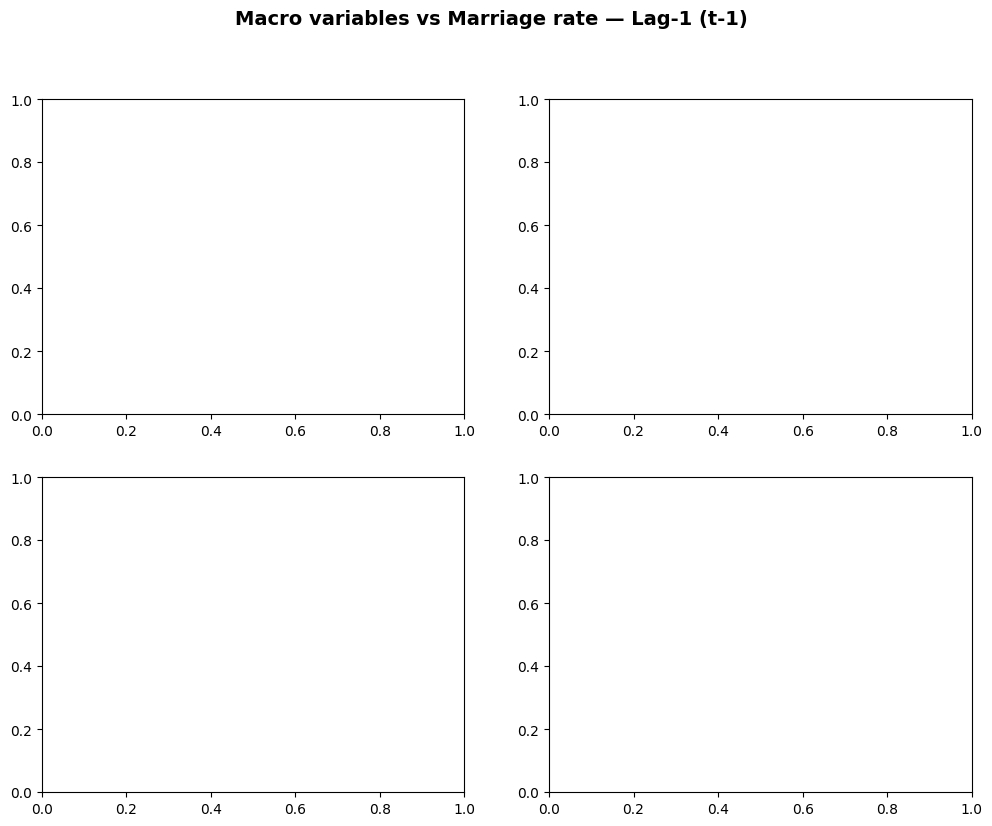

In [6]:
all_data = pd.concat([train, test])

labels = ['HPI growth (t-1)', 'HICP inflation (t-1)', 'GDP growth (t-1)', 'Unemployment (t-1)']
cols   = ['hpi_growth_lag1', 'hicp_growth_lag1', 'gdp_growth_lag1', 'unemp_rate_lag1']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Macro variables vs Marriage rate — Lag-1 (t-1)", fontsize=14, fontweight="bold")

for i in range(4):
    ax    = axes[i // 2][i % 2]
    x     = all_data[cols[i]]
    y     = all_data[target]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    sig   = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    x_line = np.linspace(x.min(), x.max(), 100)

    ax.scatter(x, y, alpha=0.6, edgecolors="k", linewidths=0.4, s=55)
    ax.plot(x_line, slope * x_line + intercept, color="crimson", linewidth=2)
    ax.set_xlabel(labels[i])
    ax.set_ylabel("Marriage rate (per 1,000)")
    ax.set_title(f"r = {r:.3f}  {sig}")

plt.tight_layout()
plt.savefig("figures/scatter_lag1.png", dpi=200, bbox_inches="tight")
plt.show()

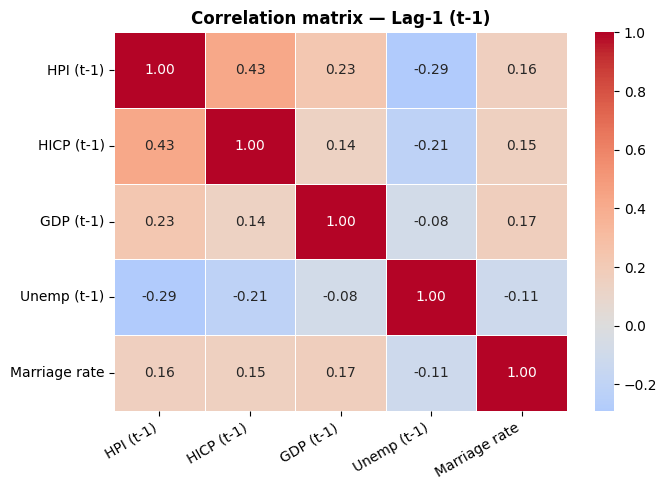

In [ ]:
all_data = pd.concat([train, test])

corr_cols   = ["hpi_growth_lag1", "hicp_growth_lag1", "gdp_growth_lag1", "unemp_rate_lag1", "marriage_rate"]
tick_labels = ["HPI (t-1)", "HICP (t-1)", "GDP (t-1)", "Unemp (t-1)", "Marriage rate"]

corr_matrix = all_data[corr_cols].corr().round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, xticklabels=tick_labels, yticklabels=tick_labels)
plt.title("Correlation matrix — Lag-1 (t-1)", fontsize=12, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/corr_lag1.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
X_train = train[features].values
y_train = train[target].values
X_test  = test[features].values
y_test  = test[target].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (26, 5)
X_test:  (65, 5)


In [ ]:
param_dist = {
    "n_estimators":     [100, 200, 300, 400, 500],
    "max_depth":        [2, 3, 4, 5],
    "learning_rate":    [0.01, 0.05, 0.1, 0.15],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0],
    "min_child_weight": [1, 2, 3, 5],
    "reg_lambda":       [0.5, 1.0, 2.0, 5.0],
    "reg_alpha":        [0, 0.1, 0.5],
}

model = XGBRegressor(objective="reg:squarederror", random_state=42, verbosity=0)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=3),
    random_state=42,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("Best hyperparameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-search.best_score_:.4f}")

Best hyperparameters:
  colsample_bytree: 1.0
  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 1
  n_estimators: 400
  reg_alpha: 0.5
  reg_lambda: 1.0
  subsample: 1.0

Best CV RMSE: 0.8490


In [ ]:
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
mae_train  = mean_absolute_error(y_train, y_pred_train)
r2_train   = r2_score(y_train, y_pred_train)

rmse_test  = mean_squared_error(y_test, y_pred_test) ** 0.5
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_test    = r2_score(y_test, y_pred_test)

print("         RMSE      MAE       R2")
print(f"Train    {rmse_train:.4f}    {mae_train:.4f}    {r2_train:.4f}")
print(f"Test     {rmse_test:.4f}    {mae_test:.4f}    {r2_test:.4f}")

         RMSE      MAE       R2
Train    0.1510    0.0932    0.9851
Test     0.7341    0.5803    0.5224


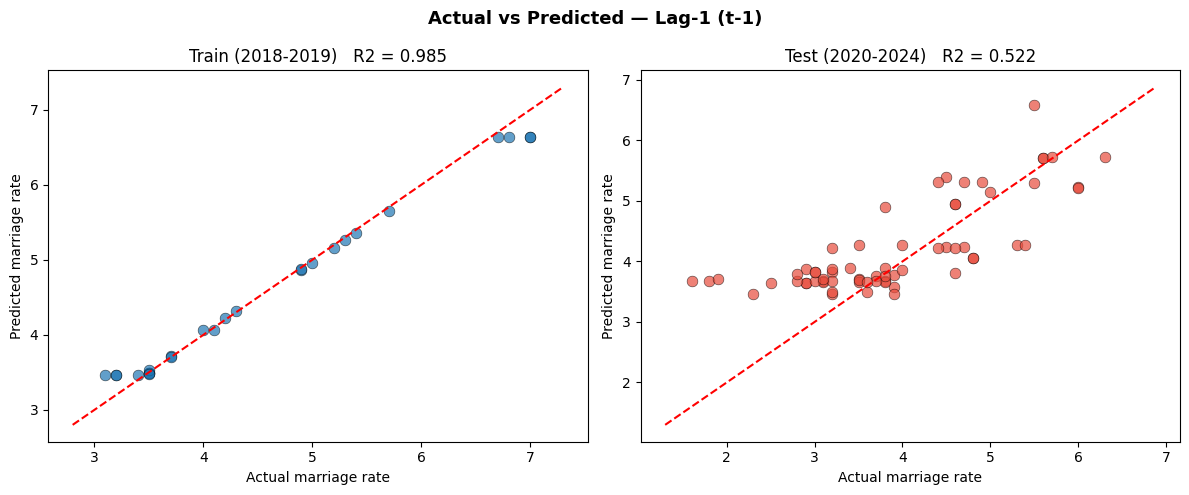

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Actual vs Predicted — Lag-1 (t-1)", fontsize=13, fontweight="bold")

axes[0].scatter(y_train, y_pred_train, alpha=0.7, edgecolors="k", linewidths=0.4, s=60)
low  = min(y_train.min(), y_pred_train.min()) - 0.3
high = max(y_train.max(), y_pred_train.max()) + 0.3
axes[0].plot([low, high], [low, high], "r--", linewidth=1.5)
axes[0].set_xlabel("Actual marriage rate")
axes[0].set_ylabel("Predicted marriage rate")
axes[0].set_title(f"Train (2018-2019)   R2 = {r2_train:.3f}")

axes[1].scatter(y_test, y_pred_test, alpha=0.7, edgecolors="k", linewidths=0.4, s=60, color="#e74c3c")
low  = min(y_test.min(), y_pred_test.min()) - 0.3
high = max(y_test.max(), y_pred_test.max()) + 0.3
axes[1].plot([low, high], [low, high], "r--", linewidth=1.5)
axes[1].set_xlabel("Actual marriage rate")
axes[1].set_ylabel("Predicted marriage rate")
axes[1].set_title(f"Test (2020-2024)   R2 = {r2_test:.3f}")

plt.tight_layout()
plt.savefig("figures/actual_pred_lag1.png", dpi=200, bbox_inches="tight")
plt.show()

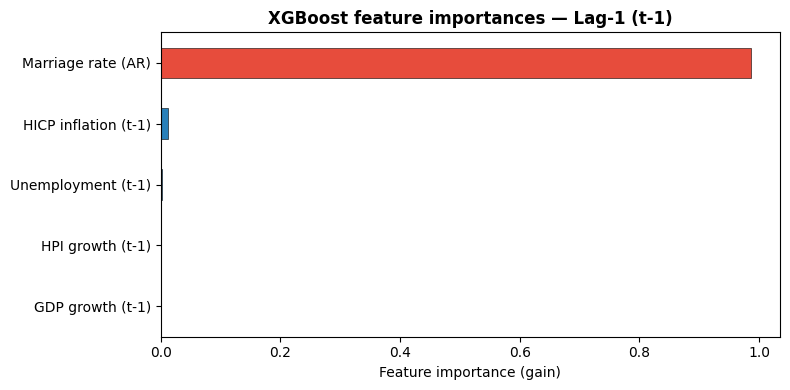

In [ ]:
feat_labels = ['HPI growth (t-1)', 'HICP inflation (t-1)', 'GDP growth (t-1)', 'Unemployment (t-1)', 'Marriage rate (AR)']

importances = pd.Series(best_model.feature_importances_, index=feat_labels).sort_values()
colors = ["#e74c3c" if "AR" in lbl else "#2980b9" for lbl in importances.index]

plt.figure(figsize=(8, 4))
importances.plot.barh(color=colors, edgecolor="k", linewidth=0.4)
plt.xlabel("Feature importance (gain)")
plt.title("XGBoost feature importances — Lag-1 (t-1)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/importance_lag1.png", dpi=200, bbox_inches="tight")
plt.show()

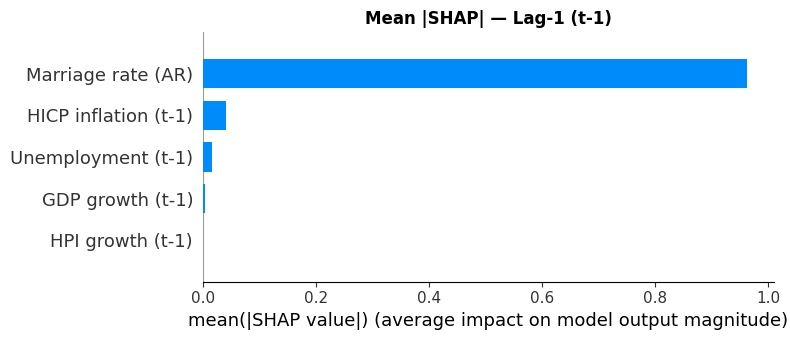

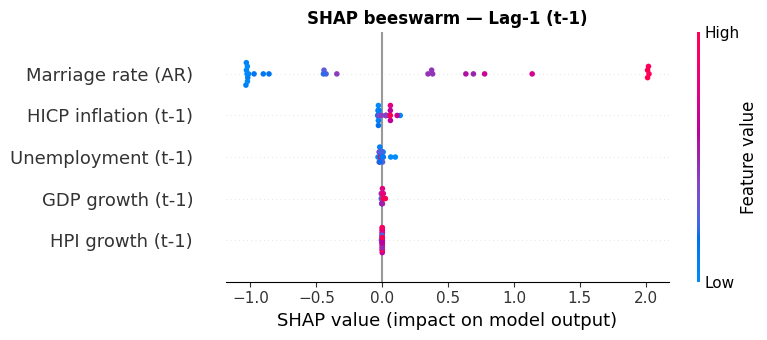

In [ ]:
feat_labels = ['HPI growth (t-1)', 'HICP inflation (t-1)', 'GDP growth (t-1)', 'Unemployment (t-1)', 'Marriage rate (AR)']

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer(X_train)

shap.summary_plot(shap_values.values, X_train, feature_names=feat_labels, plot_type="bar", show=False)
plt.title("Mean |SHAP| — Lag-1 (t-1)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/shap_bar_lag1.png", dpi=200, bbox_inches="tight")
plt.show()

shap.summary_plot(shap_values.values, X_train, feature_names=feat_labels, show=False)
plt.title("SHAP beeswarm — Lag-1 (t-1)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/shap_beeswarm_lag1.png", dpi=200, bbox_inches="tight")
plt.show()

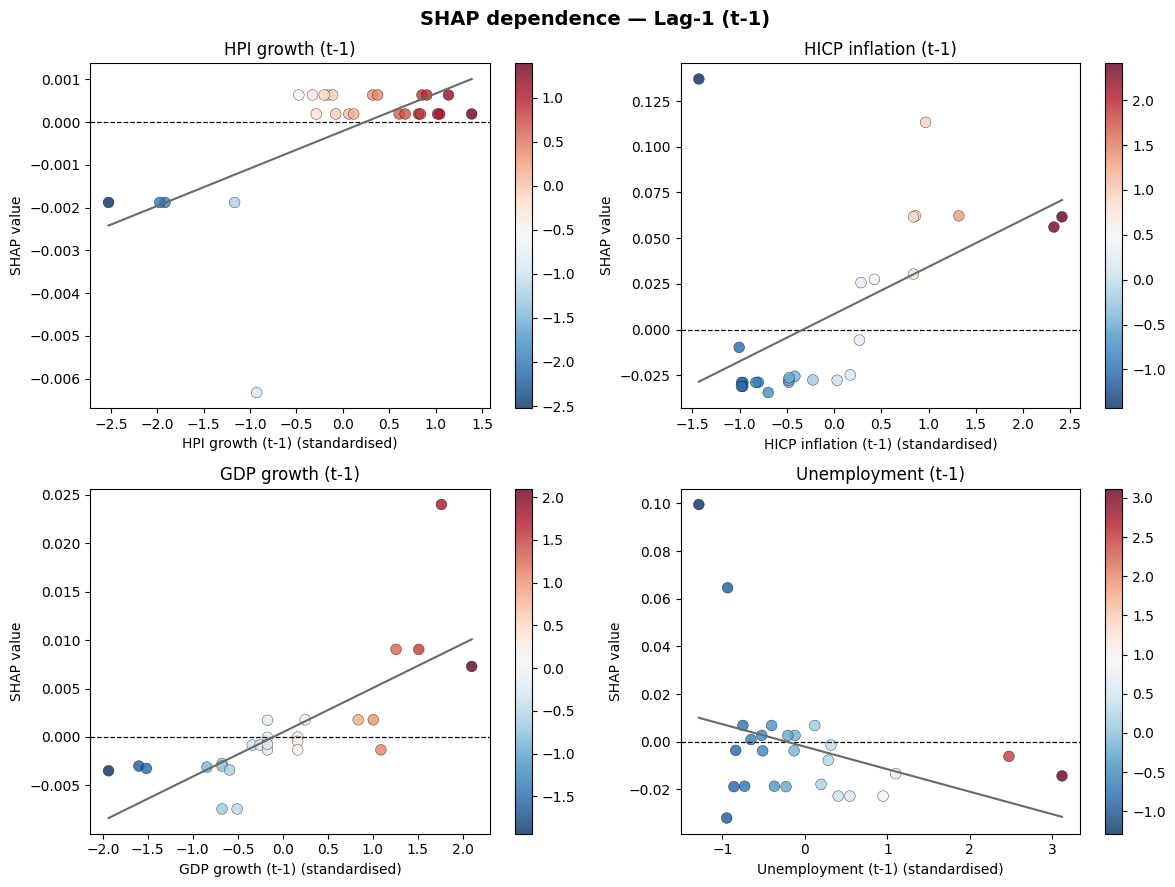

In [ ]:
feat_labels = ['HPI growth (t-1)', 'HICP inflation (t-1)', 'GDP growth (t-1)', 'Unemployment (t-1)']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("SHAP dependence — Lag-1 (t-1)", fontsize=14, fontweight="bold")

for i in range(4):
    ax  = axes[i // 2][i % 2]
    xv  = X_train[:, i]
    sv  = shap_values.values[:, i]

    sc = ax.scatter(xv, sv, c=xv, cmap="RdBu_r", alpha=0.8, edgecolors="k", linewidths=0.3, s=60)
    ax.axhline(0, color="k", linestyle="--", linewidth=0.9)
    m, b = np.polyfit(xv, sv, 1)
    xs   = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xs, m * xs + b, color="dimgray", linewidth=1.5)
    ax.set_xlabel(f"{feat_labels[i]} (standardised)")
    ax.set_ylabel("SHAP value")
    ax.set_title(feat_labels[i])
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.savefig("figures/shap_dep_lag1.png", dpi=200, bbox_inches="tight")
plt.show()